In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 │ ⚙️ CONFIG + LOAD DATASET (NO CONTEXT - NO JUDGE)
# ─────────────────────────────────────────────────────────────────────────────

import os
import re
import json
import random
from pathlib import Path
from datetime import datetime

from dotenv import load_dotenv
from openai import OpenAI

# =============================================================================
# Load environment variables
# =============================================================================
load_dotenv()

# =============================================================================
# Inference Model (API / Local)
# =============================================================================
MODEL_PROVIDER = os.getenv("MODEL_PROVIDER", "openai")
MODEL_NAME = os.getenv("MODEL_NAME", "gpt-4o-mini")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

# =============================================================================
# Benchmark Config
# =============================================================================
DATASET_PATH = "data/test-final_v3.jsonl"
RANDOM_SEED = 42
MAX_NEW_TOKENS = int(os.getenv("MAX_NEW_TOKENS", 128))
TEMPERATURE = float(os.getenv("TEMPERATURE", 0.0))
BATCH_SIZE = 8



# =============================================================================
# Run name
# =============================================================================
RUN_NAME = "gpt41_mini_domain_test_no_context"
OUTPUT_DIR = Path(f"./benchmark_outputs/{RUN_NAME}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("MODEL_PROVIDER:", MODEL_PROVIDER)
print("MODEL_NAME:", MODEL_NAME)

# =============================================================================
# Dataset utilities
# =============================================================================
def extract_context_question(user_content):
    user_content = str(user_content).strip()
    context_match = re.search(
        r"(?:Context|Ngữ cảnh)\s*:\s*(.*?)\s*(?:Question|Câu hỏi)\s*:",
        user_content, flags=re.DOTALL | re.IGNORECASE
    )
    question_match = re.search(
        r"(?:Question|Câu hỏi)\s*:\s*(.*)",
        user_content, flags=re.DOTALL | re.IGNORECASE
    )
    context = context_match.group(1).strip() if context_match else ""
    question = question_match.group(1).strip() if question_match else ""
    return context, question

REFUSAL_GOLD = "Không có thông tin trong ngữ cảnh được cung cấp."

def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

REFUSAL_GOLD_NORM = normalize_text(REFUSAL_GOLD)

def is_gold_unanswerable(ans):
    return normalize_text(ans) == REFUSAL_GOLD_NORM

# =============================================================================
# Load dataset & Transform to NO-CONTEXT messages
# =============================================================================
samples = []

NO_CONTEXT_SYSTEM_PROMPT = (
    "Bạn là trợ lý AI hỗ trợ giám thị coi thi. "
    "Hãy trả lời câu hỏi ngắn gọn và chính xác dựa trên kiến thức của bạn. "
    "Nếu không biết hoặc không chắc chắn thì hãy trả lời rằng bạn không biết."
)

with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for idx, line in enumerate(f):
        item = json.loads(line)
        messages = item["messages"]

        user_msg_raw = messages[1]["content"].strip()
        gold_answer = messages[2]["content"].strip()

        context, question = extract_context_question(user_msg_raw)

        samples.append({
            "id": f"sample_{idx}",
            "context": context,
            "question": question,
            "gold_answers": [gold_answer],
            "gold_answer": gold_answer,
            "is_unanswerable": is_gold_unanswerable(gold_answer),
            "messages": [
                {
                    "role": "system",
                    "content": NO_CONTEXT_SYSTEM_PROMPT,
                },
                {
                    "role": "user",
                    "content": f"Question:\n{question}",
                },
            ],
        })

print("Loaded samples:", len(samples))

print("\n===== Prompt Preview =====")
print("System:")
print(samples[0]["messages"][0]["content"])

print("\nUser:")
print(samples[0]["messages"][1]["content"])

print("\nGold:")
print(samples[0]["gold_answer"])

OUTPUT_DIR: /home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/gpt41_mini_domain_test_no_context
MODEL_PROVIDER: openai
MODEL_NAME: gpt-4o-mini
Loaded samples: 430

===== Prompt Preview =====
System:
Bạn là trợ lý AI hỗ trợ giám thị coi thi. Hãy trả lời câu hỏi ngắn gọn và chính xác dựa trên kiến thức của bạn. Nếu không biết hoặc không chắc chắn thì hãy trả lời rằng bạn không biết.

User:
Question:
Tài khoản đăng nhập EOS là tài khoản nào?

Gold:
Tài khoản đăng nhập EOS/PEA chính là tài khoản Wi-Fi FU-Student của sinh viên.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 │ 🚀 INITIALIZE API CLIENT (OPENAI ONLY)
# ─────────────────────────────────────────────────────────────────────────────
from openai import OpenAI

if MODEL_PROVIDER.lower() == "openai":
    client = OpenAI(api_key=OPENAI_API_KEY)
    print(f"✅ Successfully initialized OpenAI Client for model: {MODEL_NAME}")
else:
    raise ValueError(f"Pipeline này hiện chỉ hỗ trợ MODEL_PROVIDER='openai', bạn đang dùng: {MODEL_PROVIDER}")

✅ Successfully initialized OpenAI Client for model: gpt-4o-mini


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 │ 🔮 INFERENCE (NO CONTEXT - PURE API)
# ─────────────────────────────────────────────────────────────────────────────
import time
from tqdm import tqdm
from openai import InternalServerError

start_time = time.time()
predictions = []

print(f"🚀 Đang chạy Inference qua API ({MODEL_NAME})...")

for s in tqdm(samples, desc="Calling API"):

    for retry in range(3):
        try:
            response = client.chat.completions.create(
                model=MODEL_NAME,
                messages=s["messages"],
                temperature=TEMPERATURE,
                max_tokens=MAX_NEW_TOKENS,
            )

            pred_text = response.choices[0].message.content.strip()
            predictions.append({
                "text": pred_text,
            })
            break

        except InternalServerError:
            print(f"Retry {retry+1}")
            time.sleep(2)

    else:
        predictions.append("")

# Save predictions vào dictionary samples
total_time = time.time() - start_time

for s, pred in zip(samples, predictions):
    s["prediction"] = pred
    s["pred_len_tokens"] = pred["tokens"]

print("\n✅ Inference hoàn tất!")
print("⏱️ Tổng thời gian:", round(total_time, 2), "giây")
print("⚡ Latency trung bình:", round(total_time / len(samples), 4), "giây/mẫu")
print("📊 Throughput:", round(len(samples) / total_time, 2), "mẫu/giây")

print("\n--- Ví dụ mẫu đầu tiên ---")
print("❓ Câu hỏi:", samples[0]["question"])
print("💡 Dự đoán (Prediction):", samples[0]["prediction"])

🚀 Đang chạy Inference qua API (gpt-4o-mini)...


Calling API: 100%|██████████| 430/430 [10:05<00:00,  1.41s/it]


✅ Inference hoàn tất!
⏱️ Tổng thời gian: 605.11 giây
⚡ Latency trung bình: 1.4072 giây/mẫu
📊 Throughput: 0.71 mẫu/giây

--- Ví dụ mẫu đầu tiên ---
❓ Câu hỏi: Tài khoản đăng nhập EOS là tài khoản nào?
💡 Dự đoán (Prediction): {'text': 'Tài khoản đăng nhập EOS là tài khoản được sử dụng để truy cập vào hệ sinh thái EOS, thường được tạo ra thông qua một ví điện tử (wallet) và bao gồm một tên tài khoản duy nhất. Tên tài khoản này thường có định dạng từ 12 ký tự chữ cái và số.', 'tokens': 63}


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 │ 📊 EVALUATION METRICS (EM, F1, ROUGE-L, CONTAINMENT - PURE API)
# ─────────────────────────────────────────────────────────────────────────────
import re
import unicodedata
import pandas as pd
from collections import Counter


def normalize_text(text):
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"[^\w\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def compute_em(pred, gold):
    return int(normalize_text(pred) == normalize_text(gold))


def compute_f1(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens and not gold_tokens:
        return 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)
    return 2 * (precision * recall) / (precision + recall)


def lcs_length(x, y):
    dp = [[0] * (len(y) + 1) for _ in range(len(x) + 1)]
    for i in range(1, len(x) + 1):
        for j in range(1, len(y) + 1):
            if x[i - 1] == y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp[-1][-1]


def compute_rouge_l(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    lcs = lcs_length(pred_tokens, gold_tokens)
    precision = lcs / len(pred_tokens)
    recall = lcs / len(gold_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)


def compute_containment(pred, gold):
    norm_pred = normalize_text(pred)
    norm_gold = normalize_text(gold)
    if not norm_gold:
        return 0
    return int(norm_gold in norm_pred)


print("Đang tính toán các chỉ số benchmark...")
rows = []

for s in samples:
    pred = s["prediction"]
    gold = s["gold_answer"]
    gold_answers_all = s.get("gold_answers", [gold])
    is_unanswerable = bool(s.get("is_unanswerable", False))

    em = max(compute_em(pred, g) for g in gold_answers_all)
    f1 = max(compute_f1(pred, g) for g in gold_answers_all)
    rouge_l = max(compute_rouge_l(pred, g) for g in gold_answers_all)
    containment = max(compute_containment(pred, g) for g in gold_answers_all)

    # Đếm từ / token ước lượng cho API (Không phụ thuộc local tokenizer)
    pred_tokens_count = s["pred_len_tokens"]

    gold_words_count = len(gold.split())

    rows.append({
        "id": s["id"], 
        "question": s["question"], 
        "gold_answer": gold,
        "prediction": pred, 
        "is_unanswerable": is_unanswerable,
        "em": em, 
        "f1": f1,
        "rouge_l": rouge_l, 
        "containment": containment,
        "pred_len_tokens": pred_tokens_count,
        "gold_len_words": gold_words_count,
    })

df = pd.DataFrame(rows)
answerable_df = df[~df["is_unanswerable"]].copy()
unanswerable_df = df[df["is_unanswerable"]].copy()

num_samples = len(df)
avg_latency_sec = total_time / max(num_samples, 1)
throughput_sps = num_samples / total_time if total_time > 0 else 0

summary = {
    "model": MODEL_NAME.split("/")[-1],
    "evaluation_type": "NO_CONTEXT_API",
    "samples": num_samples,
    "answerable_samples": int(len(answerable_df)),
    "unanswerable_samples": int(len(unanswerable_df)),
    "answerable_em": round(answerable_df["em"].mean() * 100, 2) if len(answerable_df) else 0.0,
    "answerable_f1": round(answerable_df["f1"].mean() * 100, 2) if len(answerable_df) else 0.0,
    "answerable_rouge_l": round(answerable_df["rouge_l"].mean() * 100, 2) if len(answerable_df) else 0.0,
    "answerable_containment": round(answerable_df["containment"].mean() * 100, 2) if len(answerable_df) else 0.0,
    "overall_em": round(df["em"].mean() * 100, 2),
    "overall_f1": round(df["f1"].mean() * 100, 2),
    "overall_rouge_l": round(df["rouge_l"].mean() * 100, 2),
    "avg_pred_tokens": round(df["pred_len_tokens"].mean(), 2),
    "avg_latency_sec": round(avg_latency_sec, 4),
    "throughput_samples_per_sec": round(throughput_sps, 2),
    "total_time_sec": round(total_time, 2),
}
summary_df = pd.DataFrame([summary])

print("\n" + "=" * 70)
print(f"  BENCHMARK SUMMARY REPORT — {MODEL_NAME} (NO-CONTEXT API)")
print("=" * 70)
display(summary_df.T.rename(columns={0: "Value"}))

Đang tính toán các chỉ số benchmark...

  BENCHMARK SUMMARY REPORT — gpt-4o-mini (NO-CONTEXT API)


,Value
model,gpt-4o-mini
evaluation_type,NO_CONTEXT_API
samples,430
answerable_samples,394
unanswerable_samples,36
answerable_em,0.0
answerable_f1,16.61
answerable_rouge_l,13.53
answerable_containment,0.76
overall_em,0.0


✅ Saved metrics files:
 - benchmark_outputs/gpt41_mini_domain_test_no_context/predictions_no_context.jsonl
 - benchmark_outputs/gpt41_mini_domain_test_no_context/predictions_no_context.csv
 - benchmark_outputs/gpt41_mini_domain_test_no_context/summary_no_context.csv
 - benchmark_outputs/gpt41_mini_domain_test_no_context/summary_no_context.json


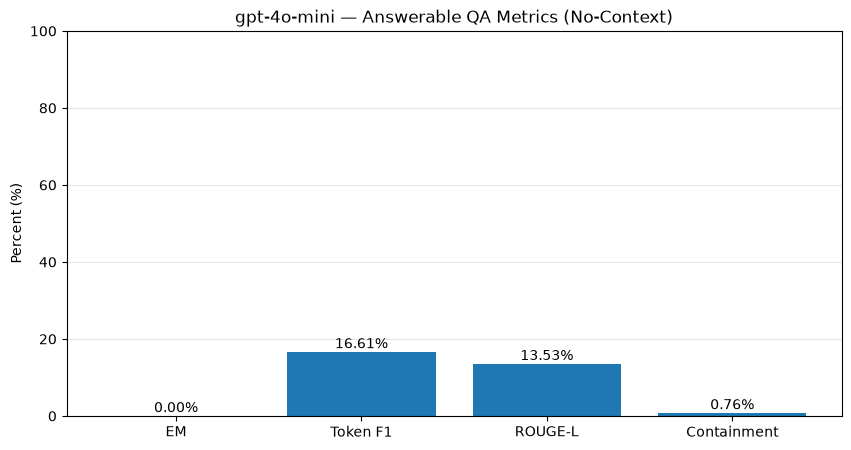

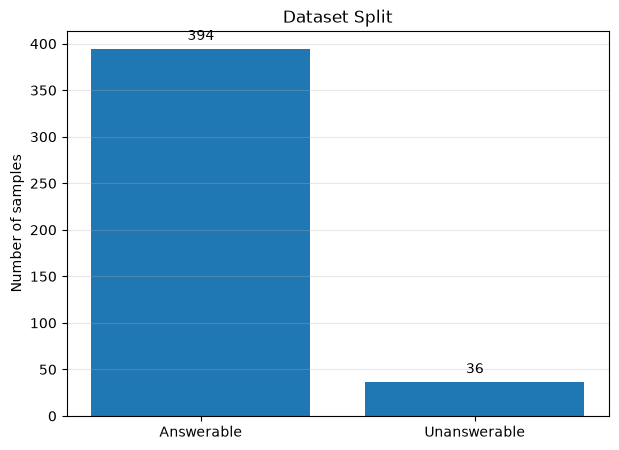

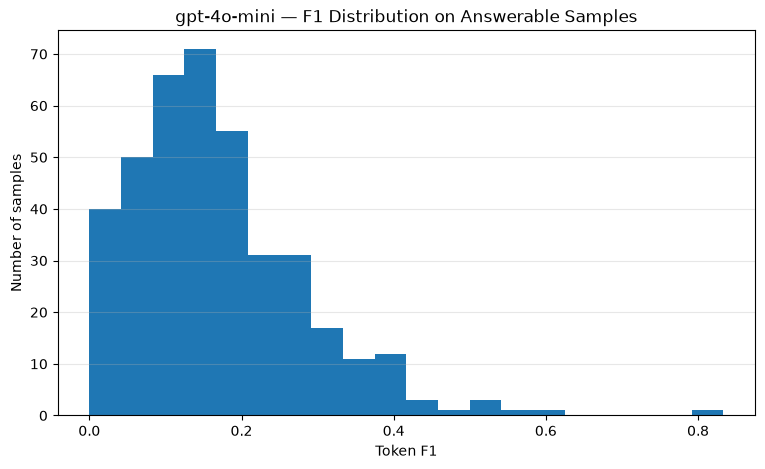


✅ All charts saved to: /home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/gpt41_mini_domain_test_no_context


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 │ 💾 SAVE RESULTS + CHARTS (DYNAMIC NAMING)
# ─────────────────────────────────────────────────────────────────────────────
import json
import matplotlib.pyplot as plt

# Đặt tên tệp động dựa theo thư mục OUTPUT_DIR
results_jsonl = OUTPUT_DIR / "predictions_no_context.jsonl"
results_csv = OUTPUT_DIR / "predictions_no_context.csv"
summary_csv = OUTPUT_DIR / "summary_no_context.csv"
summary_json = OUTPUT_DIR / "summary_no_context.json"

with open(results_jsonl, "w", encoding="utf-8") as f:
    for row in rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

df.to_csv(results_csv, index=False, encoding="utf-8-sig")
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")
with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("✅ Saved metrics files:")
print(" -", results_jsonl)
print(" -", results_csv)
print(" -", summary_csv)
print(" -", summary_json)

# 1. Chart: Answerable QA Metrics
metric_names = ["EM", "Token F1", "ROUGE-L", "Containment"]
metric_values = [
    summary["answerable_em"], 
    summary["answerable_f1"], 
    summary["answerable_rouge_l"],
    summary["answerable_containment"]
]
plt.figure(figsize=(10, 5))
plt.bar(metric_names, metric_values)
plt.ylabel("Percent (%)")
plt.title(f"{summary['model']} — Answerable QA Metrics (No-Context)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
for i, v in enumerate(metric_values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")
plt.savefig(OUTPUT_DIR / "answerable_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

# 2. Chart: Dataset Split
split_names = ["Answerable", "Unanswerable"]
split_values = [summary["answerable_samples"], summary["unanswerable_samples"]]
plt.figure(figsize=(7, 5))
plt.bar(split_names, split_values)
plt.ylabel("Number of samples")
plt.title("Dataset Split")
plt.grid(axis="y", alpha=0.3)
for i, v in enumerate(split_values):
    plt.text(i, v + 10, str(v), ha="center")
plt.savefig(OUTPUT_DIR / "dataset_split.png", dpi=200, bbox_inches="tight")
plt.show()

# 3. Chart: F1 Distribution
plt.figure(figsize=(9, 5))
plt.hist(answerable_df["f1"], bins=20)
plt.xlabel("Token F1")
plt.ylabel("Number of samples")
plt.title(f"{summary['model']} — F1 Distribution on Answerable Samples")
plt.grid(axis="y", alpha=0.3)
plt.savefig(OUTPUT_DIR / "answerable_f1_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print("\n✅ All charts saved to:", OUTPUT_DIR.resolve())

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 │ 📝 SAVE BENCHMARK REPORT (NO CONTEXT / API)
# ─────────────────────────────────────────────────────────────────────────────
report_path = OUTPUT_DIR / "benchmark_report_no_context.md"

report = f"""# Benchmark Report — {MODEL_NAME} (No-Context Direct QA)

## Model & Setup
- **Model:** `{MODEL_NAME}`
- **Provider:** API
- **Evaluation Type:** No-Context (Direct Question Answering)
- **Dataset Path:** `{DATASET_PATH}`

## Dataset Split
- Total samples: **{len(df)}**
- Answerable samples: **{summary["answerable_samples"]}**
- Unanswerable samples: **{summary["unanswerable_samples"]}**

## Main Results

### Answerable Questions
| Metric | Value |
|---|---:|
| Answerable EM | {summary["answerable_em"]:.2f}% |
| Answerable Token F1 | {summary["answerable_f1"]:.2f}% |
| Answerable ROUGE-L | {summary["answerable_rouge_l"]:.2f}% |
| Containment Accuracy | {summary["answerable_containment"]:.2f}% |

### Overall Performance & Latency
| Metric | Value |
|---|---:|
| Overall EM | {summary["overall_em"]:.2f}% |
| Overall Token F1 | {summary["overall_f1"]:.2f}% |
| Overall ROUGE-L | {summary["overall_rouge_l"]:.2f}% |
| Average Generated Tokens | {summary["avg_pred_tokens"]:.2f} |
| Average Latency | {summary["avg_latency_sec"]:.4f} sec/sample |
| Throughput | {summary["throughput_samples_per_sec"]:.2f} samples/sec |
| Total Time | {summary["total_time_sec"]:.2f} sec |

## Evaluation Methodology
This run evaluates the parametric knowledge of `{MODEL_NAME}` directly via API without providing context documents.

- **Exact Match (EM), Token F1, ROUGE-L, Containment:** Evaluated against reference gold answers using standard rule-based NLP normalization.
- **Rule-based Evaluation:** Fast, reproducible execution without local LLM Judge overhead.

## Generated Output Files
- `predictions_no_context.jsonl`
- `predictions_no_context.csv`
- `summary_no_context.csv`
- `summary_no_context.json`
- `answerable_metrics.png`
- `dataset_split.png`
- `answerable_f1_distribution.png`
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("✅ Benchmark report saved successfully:")
print(" -", report_path.resolve())

✅ Benchmark report saved successfully:
 - /home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/gpt41_mini_domain_test_no_context/benchmark_report_no_context.md
